<a href="https://colab.research.google.com/github/e23323-dot/Statistical-Learning-e23323/blob/main/Assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q. Analytical Derivation - Answers


1. Since x_{k-1}^+ ~ N(m_{k-1}, P_{k-1}) and w_{k-1} ~ N(0, Σ_p) are independent:
   E[x_k^-] = E[A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1}] = A_{k-1} m_{k-1}
   Var[x_k^-] = A_{k-1} P_{k-1} A_{k-1}^T + G_{k-1} Σ_p G_{k-1}^T
   Since linear combination of Gaussians is Gaussian: x_k^- ~ N(m_k^-, P_k^-)

2. y_k^- = H_k x_k^- + z_k, with z_k ~ N(0, Σ_m) independent of x_k^-
   E[y_k^-] = H_k E[x_k^-] = H_k m_k^-
   Var[y_k^-] = H_k P_k^- H_k^T + Σ_m
   Therefore: y_k^- ~ N(H_k m_k^-, H_k P_k^- H_k^T + Σ_m)

3. The joint distribution of (x_k^-, y_k^-) is Gaussian with:
   Mean = [m_k^-, H_k m_k^-]^T
   Covariance = [[P_k^-, P_k^- H_k^T], [H_k P_k^-, H_k P_k^- H_k^T + Σ_m]]
   This follows from the linear relationship y_k^- = H_k x_k^- + z_k

4. Using conditional Gaussian formula: 
   K_k = P_k^- H_k^T (H_k P_k^- H_k^T + Σ_m)^(-1)
   m_k = m_k^- + K_k (y_k^obs - H_k m_k^-)
   P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k) P_k^-

5. E[x_k^- | y_k^- = y_k^obs] = m_

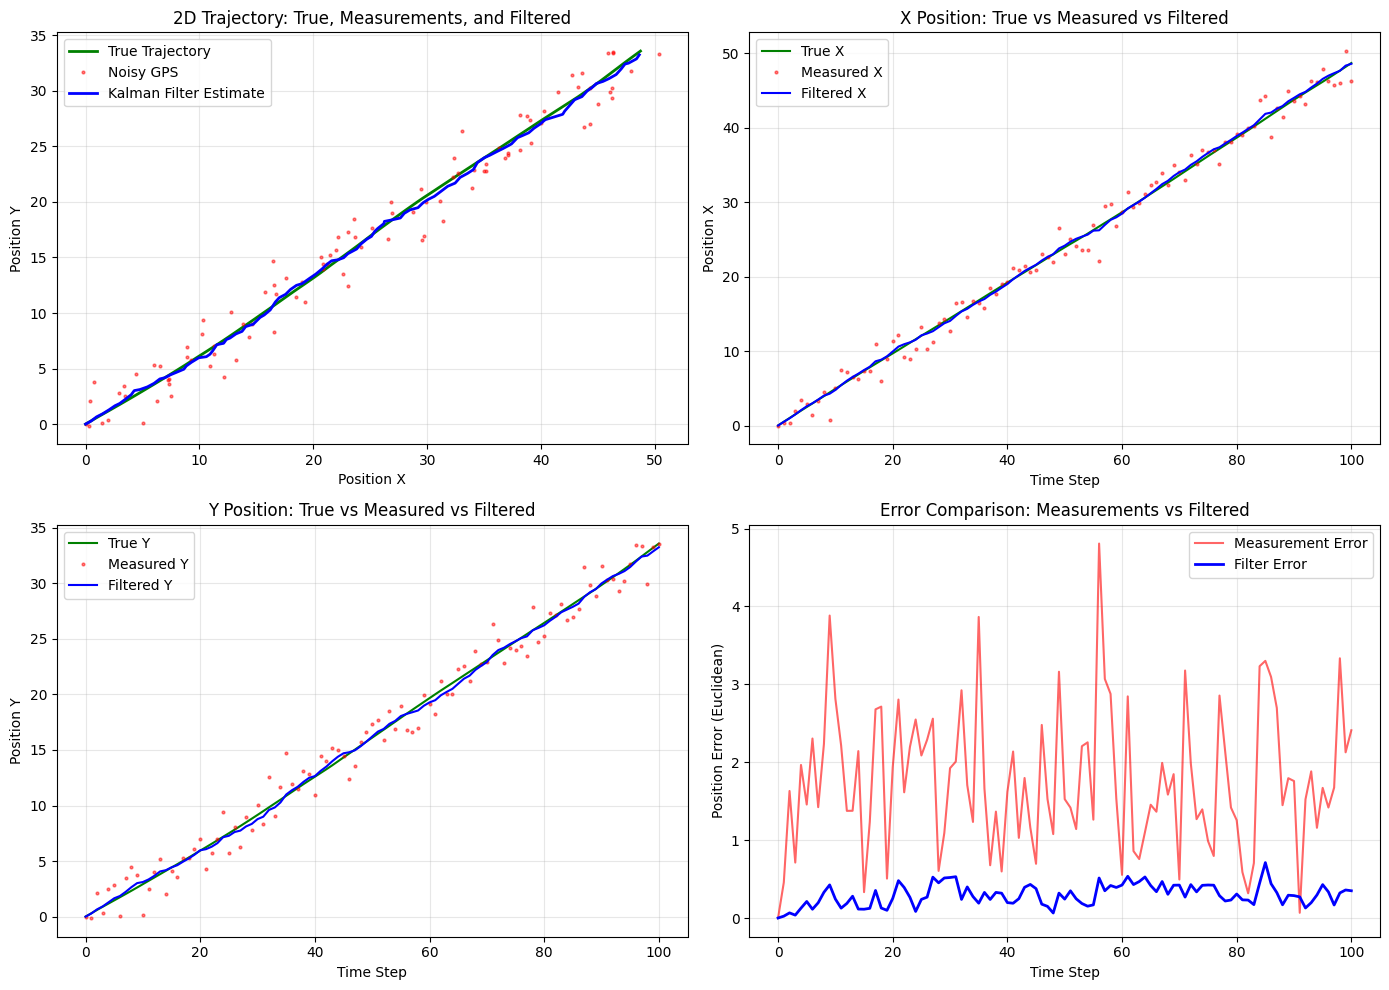


Summary of Kalman Filter Performance

Mean Measurement Error: 1.765
Mean Filter Error: 0.297
Error Reduction: 83.2%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import scipy.linalg

np.random.seed(42)

print("Q. Analytical Derivation - Answers")
print("")

print("""
1. Since x_{k-1}^+ ~ N(m_{k-1}, P_{k-1}) and w_{k-1} ~ N(0, Σ_p) are independent:
   E[x_k^-] = E[A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1}] = A_{k-1} m_{k-1}
   Var[x_k^-] = A_{k-1} P_{k-1} A_{k-1}^T + G_{k-1} Σ_p G_{k-1}^T
   Since linear combination of Gaussians is Gaussian: x_k^- ~ N(m_k^-, P_k^-)

2. y_k^- = H_k x_k^- + z_k, with z_k ~ N(0, Σ_m) independent of x_k^-
   E[y_k^-] = H_k E[x_k^-] = H_k m_k^-
   Var[y_k^-] = H_k P_k^- H_k^T + Σ_m
   Therefore: y_k^- ~ N(H_k m_k^-, H_k P_k^- H_k^T + Σ_m)

3. The joint distribution of (x_k^-, y_k^-) is Gaussian with:
   Mean = [m_k^-, H_k m_k^-]^T
   Covariance = [[P_k^-, P_k^- H_k^T], [H_k P_k^-, H_k P_k^- H_k^T + Σ_m]]
   This follows from the linear relationship y_k^- = H_k x_k^- + z_k

4. Using conditional Gaussian formula:
   K_k = P_k^- H_k^T (H_k P_k^- H_k^T + Σ_m)^(-1)
   m_k = m_k^- + K_k (y_k^obs - H_k m_k^-)
   P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k) P_k^-

5. E[x_k^- | y_k^- = y_k^obs] = m_k^- + K_k (y_k^obs - H_k m_k^-) = m_k
   Var[x_k^- | y_k^- = y_k^obs] = (I - K_k H_k) P_k^- = P_k
""")

print("")
print("Q. 1-D Example - Numerical Animation")
print("")

a = 0.9
h = 1.0
q = 0.5
r = 0.8
m0 = 0.0
P0 = 2.0
n_steps = 20

m_prior = m0
P_prior = P0
m_pred = np.zeros(n_steps + 1)
P_pred = np.zeros(n_steps + 1)
m_post = np.zeros(n_steps + 1)
P_post = np.zeros(n_steps + 1)
m_pred[0] = m0
P_pred[0] = P0
m_post[0] = m0
P_post[0] = P0

true_states = np.zeros(n_steps + 1)
true_states[0] = 0.0
measurements = np.zeros(n_steps + 1)

for k in range(1, n_steps + 1):
    true_states[k] = a * true_states[k-1] + np.random.normal(0, np.sqrt(q))
    measurements[k] = h * true_states[k] + np.random.normal(0, np.sqrt(r))

    m_k_minus = a * m_post[k-1]
    P_k_minus = a**2 * P_post[k-1] + q
    S_k = h**2 * P_k_minus + r
    K_k = P_k_minus * h / S_k
    m_k = m_k_minus + K_k * (measurements[k] - h * m_k_minus)
    P_k = (1 - K_k * h) * P_k_minus

    m_pred[k] = m_k_minus
    P_pred[k] = P_k_minus
    m_post[k] = m_k
    P_post[k] = P_k

x_grid = np.linspace(-8, 8, 500)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-8, 8)
ax.set_ylim(0, 0.8)
ax.set_xlabel('State Value')
ax.set_ylabel('Probability Density')
ax.set_title('Kalman Filter: Prior vs Posterior Distributions')
ax.grid(True, alpha=0.3)

prior_line, = ax.plot([], [], 'b-', linewidth=2, label='Prior p(x_k^- | Y_{k-1})')
post_line, = ax.plot([], [], 'r-', linewidth=2, label='Posterior p(x_k^+ | Y_k)')
true_line, = ax.plot([], [], 'g--', linewidth=1.5, label='True State')
meas_line, = ax.plot([], [], 'ko', markersize=4, label='Measurement')
ax.legend(loc='upper right')
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12)

def init():
    prior_line.set_data([], [])
    post_line.set_data([], [])
    true_line.set_data([], [])
    meas_line.set_data([], [])
    time_text.set_text('')
    return prior_line, post_line, true_line, meas_line, time_text

def animate(k):
    prior_pdf = (1 / np.sqrt(2 * np.pi * P_pred[k])) * np.exp(-0.5 * (x_grid - m_pred[k])**2 / P_pred[k])
    post_pdf = (1 / np.sqrt(2 * np.pi * P_post[k])) * np.exp(-0.5 * (x_grid - m_post[k])**2 / P_post[k])

    prior_line.set_data(x_grid, prior_pdf)
    post_line.set_data(x_grid, post_pdf)
    true_line.set_data([true_states[k]], [0.02])
    meas_line.set_data([measurements[k]], [0.01])

    y_max = max(0.8, np.max(prior_pdf) * 1.1, np.max(post_pdf) * 1.1)
    ax.set_ylim(0, min(y_max, 1.2))
    time_text.set_text(f'Step k = {k}')

    return prior_line, post_line, true_line, meas_line, time_text

anim = FuncAnimation(fig, animate, init_func=init, frames=range(n_steps + 1), interval=800, blit=True, repeat=True)
plt.close()
HTML(anim.to_html5_video())

print("Animation showing prior and posterior distributions over time")
print("Blue curve: Prior p(x_k^- | Y_{k-1})")
print("Red curve: Posterior p(x_k^+ | Y_k)")
print("Green dash: True state value")
print("Black dot: Noisy measurement")

print("")
print("Q. 2D-Position Estimation - Part A")
print("")

print("""
State vector: x_k = [p_x(k), p_y(k), v_x(k), v_y(k)]^T

For constant velocity model:
p_x(k) = p_x(k-1) + v_x(k-1) * Δt
p_y(k) = p_y(k-1) + v_y(k-1) * Δt
v_x(k) = v_x(k-1)
v_y(k) = v_y(k-1)

Therefore:
A = [[1, 0, Δt, 0],
     [0, 1, 0, Δt],
     [0, 0, 1, 0],
     [0, 0, 0, 1]]

Measurement: y_k = [p_x_meas(k), p_y_meas(k)]^T

Therefore:
H = [[1, 0, 0, 0],
     [0, 1, 0, 0]]

Process noise acts on acceleration (jerk):
a_x = w_x, a_y = w_y
Position change: 0.5 * w * Δt^2
Velocity change: w * Δt

Therefore:
G = [[0.5*Δt^2, 0],
     [0, 0.5*Δt^2],
     [Δt, 0],
     [0, Δt]]
""")

print("")
print("Q. 2D-Position Estimation - Part B")
print("")

dt = 0.1
n_steps_2d = 100

A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

G = np.array([[0.5*dt**2, 0],
              [0, 0.5*dt**2],
              [dt, 0],
              [0, dt]])

Sigma_p = np.array([[0.5, 0],
                    [0, 0.5]])

Sigma_m = np.array([[2.0, 0],
                    [0, 2.0]])

m0_2d = np.array([0, 0, 5, 3])
P0_2d = np.eye(4) * 0.1

true_states_2d = np.zeros((n_steps_2d + 1, 4))
true_states_2d[0] = m0_2d
measurements_2d = np.zeros((n_steps_2d + 1, 2))

for k in range(1, n_steps_2d + 1):
    w = np.random.multivariate_normal(np.zeros(2), Sigma_p)
    true_states_2d[k] = A @ true_states_2d[k-1] + G @ w
    z = np.random.multivariate_normal(np.zeros(2), Sigma_m)
    measurements_2d[k] = H @ true_states_2d[k] + z

m_post_2d = np.zeros((n_steps_2d + 1, 4))
P_post_2d = np.zeros((n_steps_2d + 1, 4, 4))
m_post_2d[0] = m0_2d
P_post_2d[0] = P0_2d

m_pred_2d = np.zeros((n_steps_2d + 1, 4))
P_pred_2d = np.zeros((n_steps_2d + 1, 4, 4))

for k in range(1, n_steps_2d + 1):
    m_k_minus = A @ m_post_2d[k-1]
    P_k_minus = A @ P_post_2d[k-1] @ A.T + G @ Sigma_p @ G.T

    S_k = H @ P_k_minus @ H.T + Sigma_m
    K_k = P_k_minus @ H.T @ np.linalg.inv(S_k)

    innovation = measurements_2d[k] - H @ m_k_minus
    m_k = m_k_minus + K_k @ innovation
    P_k = (np.eye(4) - K_k @ H) @ P_k_minus

    m_pred_2d[k] = m_k_minus
    P_pred_2d[k] = P_k_minus
    m_post_2d[k] = m_k
    P_post_2d[k] = P_k

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(true_states_2d[:, 0], true_states_2d[:, 1], 'g-', linewidth=2, label='True Trajectory')
ax1.plot(measurements_2d[:, 0], measurements_2d[:, 1], 'ro', markersize=2, alpha=0.5, label='Noisy GPS')
ax1.plot(m_post_2d[:, 0], m_post_2d[:, 1], 'b-', linewidth=2, label='Kalman Filter Estimate')
ax1.set_xlabel('Position X')
ax1.set_ylabel('Position Y')
ax1.set_title('2D Trajectory: True, Measurements, and Filtered')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(range(n_steps_2d + 1), true_states_2d[:, 0], 'g-', label='True X')
ax2.plot(range(n_steps_2d + 1), measurements_2d[:, 0], 'ro', markersize=2, alpha=0.5, label='Measured X')
ax2.plot(range(n_steps_2d + 1), m_post_2d[:, 0], 'b-', label='Filtered X')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Position X')
ax2.set_title('X Position: True vs Measured vs Filtered')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(range(n_steps_2d + 1), true_states_2d[:, 1], 'g-', label='True Y')
ax3.plot(range(n_steps_2d + 1), measurements_2d[:, 1], 'ro', markersize=2, alpha=0.5, label='Measured Y')
ax3.plot(range(n_steps_2d + 1), m_post_2d[:, 1], 'b-', label='Filtered Y')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Position Y')
ax3.set_title('Y Position: True vs Measured vs Filtered')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
error_meas = np.sqrt((true_states_2d[:, 0] - measurements_2d[:, 0])**2 +
                     (true_states_2d[:, 1] - measurements_2d[:, 1])**2)
error_filter = np.sqrt((true_states_2d[:, 0] - m_post_2d[:, 0])**2 +
                       (true_states_2d[:, 1] - m_post_2d[:, 1])**2)
ax4.plot(range(n_steps_2d + 1), error_meas, 'r-', label='Measurement Error', alpha=0.6)
ax4.plot(range(n_steps_2d + 1), error_filter, 'b-', label='Filter Error', linewidth=2)
ax4.set_xlabel('Time Step')
ax4.set_ylabel('Position Error (Euclidean)')
ax4.set_title('Error Comparison: Measurements vs Filtered')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("")
print("Summary of Kalman Filter Performance")
print("")
print(f"Mean Measurement Error: {np.mean(error_meas):.3f}")
print(f"Mean Filter Error: {np.mean(error_filter):.3f}")
print(f"Error Reduction: {(1 - np.mean(error_filter)/np.mean(error_meas))*100:.1f}%")